# Modelado Estocástico

## Test de Dickey-Fuller Aumentado (ADF)

En esta práctica vamos a estudiar el orden de integración de una serie
de precios utilizando el test de Dickey-Fuller aumentado (ADF).

La pregunta que queremos responder es:

> ¿El precio del trigo es una serie estacionaria o necesitamos diferenciarla para obtener una serie estacionaria?

Recordemos que:

- una serie estacionaria es I(0);
- si una serie no es estacionaria pero su primera diferencia es
  estacionaria, decimos que es I(1).

El ADF contrasta la hipótesis nula de raíz unitaria frente a la
alternativa de estacionariedad.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

Vamos a utilizar el archivo `wheat.xlsx` que contiene datos con precios del trigo provenientes de la Pink Sheet (World Bank) https://www.worldbank.org/en/research/commodity-markets


In [ ]:
df = pd.read_excel('wheat.xlsx')
df.head()

,yearmm,wheat_srw,wheat_hrw
0,1980M01,169.71,175.63
1,1980M02,170.49,172.70
2,1980M03,162.40,163.51
3,1980M04,155.80,156.53
4,1980M05,156.20,161.30


Generamos una nueva columna de índice con la fecha con frecuencia mensual y formatos adecuados utilizando la primera fila como fecha de referencia.

In [ ]:
inicio = pd.to_datetime(
    df["yearmm"].iloc[0],
    format="%YM%m"
)

df["date"] = pd.period_range(
    start=inicio,
    periods=len(df),
    freq="M"
)

df = df.set_index("date")

Por precaución, para poder operar nos aseguramos que el tipo cargado en `wheat_srw` sea el correcto convirtiéndolo a numérico.

In [ ]:
df["wheat_srw"] = pd.to_numeric(
    df["wheat_srw"],
    errors="coerce"
)

Calculamos el logaritmo del precio:

$$ln(ws_t) = \ln(P_t)$$



In [ ]:
df_log_ws = np.log(df["wheat_srw"])

Gráficamente:

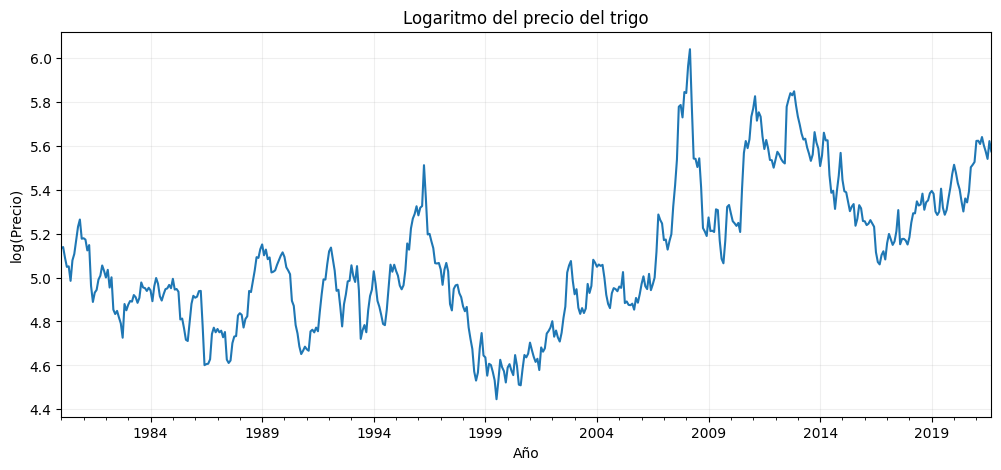

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

df_log_ws.plot(ax=ax)

ax.set_title("Logaritmo del precio del trigo")
ax.set_xlabel("Año")
ax.set_ylabel("log(Precio)")
ax.grid(alpha=0.2)

plt.show()

Luego, lo utilizamos obtener los retornos logarítmicos:

$$dlws_t = ln(ws_t) - ln(ws_{t-1}) = \Delta \ln(P_t)$$

In [ ]:
df_log_ws = np.log(df["wheat_srw"])
df["dlws"] = df_log_ws.diff()
df.head()


,yearmm,wheat_srw,wheat_hrw,dlws
date,,,,
1980-01,1980M01,169.71,175.63,NaN
1980-02,1980M02,170.49,172.70,0.004586
1980-03,1980M03,162.40,163.51,-0.048614
1980-04,1980M04,155.80,156.53,-0.041489
1980-05,1980M05,156.20,161.30,0.002564


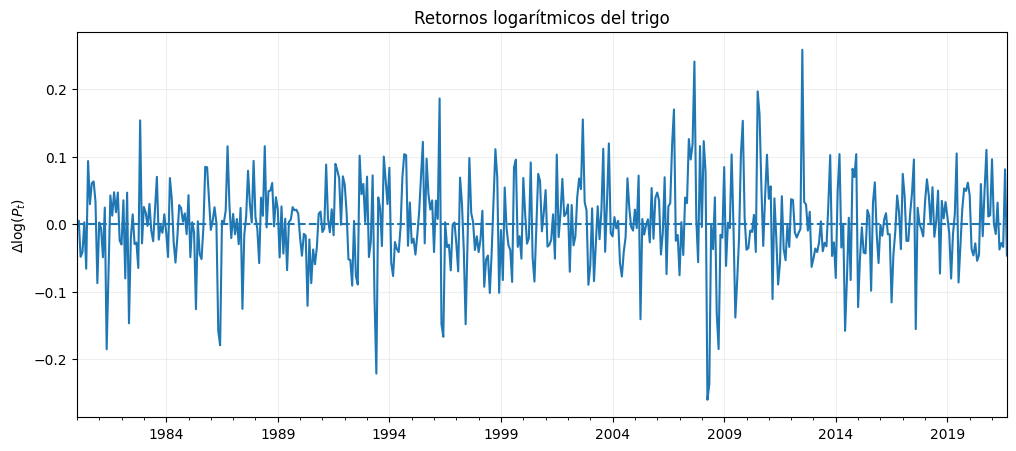

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

df["dlws"].plot(ax=ax)

ax.set_title("Retornos logarítmicos del trigo")
ax.set_xlabel("")
ax.set_ylabel(r"$\Delta \log(P_t)$")
ax.axhline(0, linestyle="--")
ax.grid(alpha=0.2)

plt.show()

Guardamos en y los retornos logarítmicos sin el NaN de la primera fila (ni cualquier otro que se encontrara en esa columna).

In [ ]:
y = df["dlws"].dropna()

## Dickey Fuller Aumentado (ADF)


`statsmodels.tsa.stattools.adfuller`
permite especificar:

### Componentes determinísticos

- `regression="n"`: sin constante ni tendencia.
- `regression="c"`: constante.
- `regression="ct"`: constante y tendencia lineal.
- `regression="ctt"`: constante, tendencia lineal y tendencia cuadrática.

### Selección de rezagos

El argumento `autolag` permite:

- `"AIC"` (por defecto)
- `"BIC"` (Bayesian Information Criterion = Schwarz Information Criterion)
- `"t-stat"`
- `None`

Si `maxlag` no se especifica, `statsmodels` utiliza su regla automática
para determinar el máximo número de rezagos.

https://www.statsmodels.org/dev/generated/statsmodels.tsa.stattools.adfuller.html



### Primer ADF

Comenzamos aplicando el ADF a los retornos logarítmicos.

Utilizamos:

- constante;
- selección de rezagos mediante `t-stat`.

Recordemos que la hipótesis nula es:

$
H_0:\text{hay raíz unitaria}
$

y la alternativa:

$
H_A:\text{la serie es estacionaria}.
$

In [ ]:
test = adfuller(
    y,
    regression="c",
    autolag="t-stat"
)

test

(np.float64(-8.29298506420239),
 np.float64(4.212621704639424e-13),
 8,
 491,
 {'1%': np.float64(-3.4437386290417082),
  '5%': np.float64(-2.867444458865948),
  '10%': np.float64(-2.5699148492415413)},
 np.float64(1.7290431693153947))

La salida con los resultados del ADF nos indican:

In [ ]:
def imprimir_resultados_sin_regresults(test_res):
  print(f"Estadístico ADF : {test_res[0]:.4f}")
  print(f"p-valor         : {test_res[1]:.4f}")
  print(f"Rezagos         : {test_res[2]}")
  print(f"Observaciones    : {test_res[3]}")
  print("Valores críticos:")

  for nivel, valor in test_res[4].items():
      print(f"  {nivel}: {valor:.4f}")

In [ ]:
imprimir_resultados_sin_regresults(test)

Estadístico ADF : -8.2930
p-valor         : 0.0000
Rezagos         : 8
Observaciones    : 491
Valores críticos:
  1%: -3.4437
  5%: -2.8674
  10%: -2.5699


### Importante

El estadístico ADF no se compara con los valores críticos habituales
de una distribución t.

Bajo la hipótesis nula de raíz unitaria, la distribución del estadístico
no es una distribución t convencional.

Por eso `statsmodels` proporciona directamente los valores críticos y
el p-value correspondientes al test ADF.

Como el contraste es unilateral hacia la izquierda, los valores críticos
son negativos.

Rechazamos en la cola izquierda la $H_0$: serie no estacionaria.

## ¿Qué hay detrás del ADF?

Para una especificación con constante y tendencia, la regresión
auxiliar tiene la forma:

$
\Delta y_t =
c + \beta t +
\gamma y_{t-1}
+
\sum_{i=1}^{p}\phi_i\Delta y_{t-i}
+\varepsilon_t.
$

La hipótesis de raíz unitaria se formula como:

$
H_0:\gamma=0
$

frente a:

$
H_A:\gamma<0.
$

Los rezagos de las diferencias se incorporan para controlar la
autocorrelación de los residuos.

Al incorporar el parámetro `regresults = True` podemos obtener la regresión auxiliar OLS utilizada para construir el estadístico ADF

In [ ]:
def imprimir_resultados_con_regresults(test_res):
  print(f"Estadístico ADF: {test_res[0]:.4f}")
  print(f"p-valor:         {test_res[1]:.4f}")
  for nivel, valor in test_res[2].items():
      print(f"  {nivel}: {valor:.4f}")

  print(test_res[3].resols.summary())

In [ ]:
test_adf = adfuller(y, regression="c", autolag="t-stat", regresults=True)
imprimir_resultados_con_regresults(test_adf)


Estadístico ADF: -8.2930
p-valor:         0.0000
  1%: -3.4437
  5%: -2.8674
  10%: -2.5699
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.436
Model:                            OLS   Adj. R-squared:                  0.425
Method:                 Least Squares   F-statistic:                     41.25
Date:                Thu, 13 Aug 2026   Prob (F-statistic):           1.92e-54
Time:                        23:40:10   Log-Likelihood:                 664.56
No. Observations:                 491   AIC:                            -1309.
Df Residuals:                     481   BIC:                            -1267.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------

Analicemos los resultados de las diversas configuraciones para los parámetros del método `adfuller` (Omitir `maxlag` implica usar el criterio de Schwert, por defecto).

In [ ]:
resultados = []

configuraciones = [
    (17, "c", "t-stat"),
    (17, "ct", "t-stat"),
    (17, "ctt", "t-stat"),
    (17, "n", "t-stat"),
    (None, "c", "t-stat"),
    (None, "c", "AIC"),
    (None, "c", "BIC"),
]

for maxlag, regression, autolag in configuraciones:

    resultado = adfuller(
        y,
        maxlag=maxlag,
        regression=regression,
        autolag=autolag,
    )

    resultados.append({
        "maxlag": maxlag,
        "regression": regression,
        "autolag": autolag,
        "ADF": resultado[0],
        "p_value": resultado[1],
        "lags": resultado[2],
        "n_obs": resultado[3],
    })

pd.DataFrame(resultados)

,maxlag,regression,autolag,ADF,p_value,lags,n_obs
0,17.0,c,t-stat,-8.292985,4.212622e-13,8,491
1,17.0,ct,t-stat,-8.329124,1.241124e-11,8,491
2,17.0,ctt,t-stat,-8.336452,5.041771e-11,8,491
3,17.0,n,t-stat,-8.296593,6.896382e-14,8,491
4,NaN,c,t-stat,-8.292985,4.212622e-13,8,491
5,NaN,c,AIC,-8.292985,4.212622e-13,8,491
6,NaN,c,BIC,-18.724549,2.032008e-30,0,499


Repetimos el ADF, pero ahora con el parámetro `regression = "ct"` y observamos la regresión auxiliar:

In [ ]:
test_adf_ct = adfuller(y, regression="ct", autolag="t-stat", regresults=True)
imprimir_resultados_con_regresults(test_adf_ct)

Estadístico ADF: -8.3291
p-valor:         0.0000
  1%: -3.9773
  5%: -3.4195
  10%: -3.1323
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.436
Model:                            OLS   Adj. R-squared:                  0.425
Method:                 Least Squares   F-statistic:                     37.16
Date:                Thu, 13 Aug 2026   Prob (F-statistic):           9.19e-54
Time:                        23:40:10   Log-Likelihood:                 664.90
No. Observations:                 491   AIC:                            -1308.
Df Residuals:                     480   BIC:                            -1262.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------

### ¿Cuántos rezagos debemos utilizar?

La elección de \(p\) es importante.

Si utilizamos muy pocos rezagos, puede quedar autocorrelación en los
residuos de la regresión ADF.

Si utilizamos demasiados rezagos, aumentamos el número de parámetros
estimados y podemos reducir el poder estadístico del test.

Por lo tanto, el objetivo no es simplemente elegir el número de rezagos
que produzca el p-value que más nos convenga.

Número de lags utilizados:

In [ ]:
test_lags = adfuller(y, regression="ct", autolag="t-stat")
imprimir_resultados_sin_regresults(test_lags)
k_lags = test_lags[2]


Estadístico ADF : -8.3291
p-valor         : 0.0000
Rezagos         : 8
Observaciones    : 491
Valores críticos:
  1%: -3.9773
  5%: -3.4195
  10%: -3.1323


En este punto vamos a realizar la regresión manualmente para comparar los resultados con la provista por la librería.

In [ ]:
T = len(y)

t = np.arange(1, T + 1)

dy = y.diff()

X = pd.DataFrame(
    {
        "const": 1.0,
        "trend": t,
        "y_lag1": y.shift(1),
    },
    index=y.index,
)

Generamos los X e Y para la regresión OLS.

Los términos `dy_lag1`, `dy_lag2`, ... corresponden a:

$
\Delta y_{t-1},\Delta y_{t-2},\ldots,\Delta y_{t-k}.
$

In [ ]:
for i in range(1, k_lags + 1):
    X[f"dy_lag{i}"] = dy.shift(i)

Y = dy
data = pd.concat([Y, X], axis=1).dropna()

Y_ols = data.iloc[:, 0]
X_ols = data.iloc[:, 1:]

data

,dlws,const,trend,y_lag1,dy_lag1,dy_lag2,dy_lag3,dy_lag4,dy_lag5,dy_lag6,dy_lag7,dy_lag8
date,,,,,,,,,,,,
1980-11,-0.030193,1.0,10,0.063114,0.002546,0.031221,-0.063971,0.159480,-0.068726,0.044053,0.007125,-0.053200
1980-12,-0.120450,1.0,11,0.032921,-0.030193,0.002546,0.031221,-0.063971,0.159480,-0.068726,0.044053,0.007125
1981-01,0.089785,1.0,12,-0.087529,-0.120450,-0.030193,0.002546,0.031221,-0.063971,0.159480,-0.068726,0.044053
1981-02,-0.008473,1.0,13,0.002256,0.089785,-0.120450,-0.030193,0.002546,0.031221,-0.063971,0.159480,-0.068726
1981-03,-0.043050,1.0,14,-0.006216,-0.008473,0.089785,-0.120450,-0.030193,0.002546,0.031221,-0.063971,0.159480
...,...,...,...,...,...,...,...,...,...,...,...,...
2021-05,-0.069430,1.0,496,0.031788,0.046547,-0.015410,-0.095307,0.083103,0.001708,-0.098733,0.059737,0.068180
2021-06,0.009549,1.0,497,-0.037642,-0.069430,0.046547,-0.015410,-0.095307,0.083103,0.001708,-0.098733,0.059737
2021-07,-0.005907,1.0,498,-0.028093,0.009549,-0.069430,0.046547,-0.015410,-0.095307,0.083103,0.001708,-0.098733


Corremos la regresión:

In [ ]:
res = sm.OLS(Y_ols, X_ols).fit()
print(res.summary())


                            OLS Regression Results                            
Dep. Variable:                   dlws   R-squared:                       0.436
Model:                            OLS   Adj. R-squared:                  0.425
Method:                 Least Squares   F-statistic:                     37.16
Date:                Thu, 13 Aug 2026   Prob (F-statistic):           9.19e-54
Time:                        23:40:11   Log-Likelihood:                 664.90
No. Observations:                 491   AIC:                            -1308.
Df Residuals:                     480   BIC:                            -1262.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0034      0.006     -0.574      0.5

In [ ]:
print("Coeficiente de y_{t-1}:")
print(res.params["y_lag1"])

print("\nEstadístico t:")
print(res.tvalues["y_lag1"])

Coeficiente de y_{t-1}:
-1.0765914429181938

Estadístico t:
-8.329124154425488


El coeficiente asociado a $y_{t-1}$ es $\hat{\gamma}$.

El estadístico ADF corresponde al estadístico asociado a este
coeficiente, pero **no debe confundirse con un estadístico t convencional**,
porque bajo la hipótesis nula su distribución no es la distribución t
usual.

## Test de Raíces Unitarias Dickey Fuller GLS (DFGLS):

El test DFGLS (Elliott, Rothenberg y Stock, 1996) es una versión del test de Dickey-Fuller que utiliza una transformación GLS para remover los componentes determinísticos antes de realizar el contraste de raíz unitaria.
https://arch.readthedocs.io/en/latest/unitroot/generated/arch.unitroot.DFGLS.html#arch.unitroot.DFGLS

Para poder utilizar el test DFGLS debemos instalar la biblioteca ARCH.

In [ ]:
!pip install arch
from arch.unitroot import DFGLS

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 13.6 MB/s eta 0:00:00


### Variaciones de los parámetros en DFGLS:

In [ ]:
dfgls_c = DFGLS(
    y,
    trend="c",
    method="t-stat"
)

print(dfgls_c.summary())

      Dickey-Fuller GLS Results      
Test Statistic                 -8.224
P-value                         0.000
Lags                                8
-------------------------------------

Trend: Constant
Critical Values: -2.61 (1%), -1.99 (5%), -1.67 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.


In [ ]:
dfgls_ct = DFGLS(
    y,
    trend="ct",
    method="t-stat"
)

print(dfgls_ct.summary())

      Dickey-Fuller GLS Results      
Test Statistic                 -7.970
P-value                         0.000
Lags                                8
-------------------------------------

Trend: Constant and Linear Time Trend
Critical Values: -3.45 (1%), -2.89 (5%), -2.60 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.


DFGLS también nos permite obtener el resumen de la regresión OLS por detrás:

In [ ]:
print(dfgls_ct.regression.summary())

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.430
Model:                            OLS   Adj. R-squared (uncentered):              0.419
Method:                 Least Squares   F-statistic:                              40.41
Date:                Thu, 13 Aug 2026   Prob (F-statistic):                    1.48e-53
Time:                        23:40:21   Log-Likelihood:                          662.15
No. Observations:                 491   AIC:                                     -1306.
Df Residuals:                     482   BIC:                                     -1269.
Df Model:                           9                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

### Ejemplo completo: determinación del orden de integración

Ahora aplicamos el procedimiento completo al logaritmo del precio del trigo.

#### Paso 1

Aplicamos ADF sobre la serie en niveles.

Comenzamos permitiendo una constante y una tendencia determinística
lineal (regression="ct").

In [ ]:
df_log_ws

,wheat_srw
date,
1980-01,5.134091
1980-02,5.138677
1980-03,5.090062
1980-04,5.048573
1980-05,5.051137
...,...
2021-05,5.602062
2021-06,5.573969
2021-07,5.539970


In [ ]:
x = df_log_ws.dropna()
test_adf = adfuller(
    x,
    regression="ct",
    autolag="t-stat",
    regresults=True
)

imprimir_resultados_con_regresults(test_adf)

Estadístico ADF: -3.1031
p-valor:         0.1055
  1%: -3.9773
  5%: -3.4195
  10%: -3.1323
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.085
Model:                            OLS   Adj. R-squared:                  0.064
Method:                 Least Squares   F-statistic:                     4.047
Date:                Thu, 13 Aug 2026   Prob (F-statistic):           1.10e-05
Time:                        23:40:21   Log-Likelihood:                 669.79
No. Observations:                 491   AIC:                            -1316.
Df Residuals:                     479   BIC:                            -1265.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------

El ADF tiene un p-value mayor a 0.10 y consecuentemnte no rechazamos $H_0$ (la serie es NO estacionaria).

Notemos también que la tendencia determinística (TD) es significativa (p-val 0.009 en x11).

### Paso 2

Si no rechazamos la hipótesis nula de raíz unitaria en niveles,
analizamos la serie en primeras diferencias.

Las primeras diferencias del log-precio es:

$
\Delta\ln(P_t)
=
\ln(P_t)-\ln(P_{t-1}),
$

que corresponde al retorno logarítmico.

In [ ]:
y = x.diff().dropna()

ADF de la diferencia con tendencia determinística lineal (TD)

In [ ]:
test_adf = adfuller(y, regression="ct", autolag="t-stat", regresults=True)
imprimir_resultados_con_regresults(test_adf)

Estadístico ADF: -8.3291
p-valor:         0.0000
  1%: -3.9773
  5%: -3.4195
  10%: -3.1323
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.436
Model:                            OLS   Adj. R-squared:                  0.425
Method:                 Least Squares   F-statistic:                     37.16
Date:                Thu, 13 Aug 2026   Prob (F-statistic):           9.19e-54
Time:                        23:40:21   Log-Likelihood:                 664.90
No. Observations:                 491   AIC:                            -1308.
Df Residuals:                     480   BIC:                            -1262.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------

Notemos que la serie en primeras diferencias es I(0), ya que el p-value asociado al ADF es menor a 0.0001, pero notemos también que la TD no es significativa (x10). Entonces debemos repetir el ADF sin TD lineal, o sea, opción regression="c" (ya que en el anterior, la TD resultó no significativa):

In [ ]:
test_adf = adfuller(
    y,
    regression="c",
    autolag="t-stat",
    regresults=True
)

imprimir_resultados_con_regresults(test_adf)

Estadístico ADF: -8.2930
p-valor:         0.0000
  1%: -3.4437
  5%: -2.8674
  10%: -2.5699
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.436
Model:                            OLS   Adj. R-squared:                  0.425
Method:                 Least Squares   F-statistic:                     41.25
Date:                Thu, 13 Aug 2026   Prob (F-statistic):           1.92e-54
Time:                        23:40:21   Log-Likelihood:                 664.56
No. Observations:                 491   AIC:                            -1309.
Df Residuals:                     481   BIC:                            -1267.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------

Si rechazamos la hipótesis nula de raíz unitaria para la serie en primeras diferencias, tenemos evidencia de que:

$
\Delta \log(P_t)
$

es I(0) y si la TD no es significativa, podemos afirmar que es estacionaria (respecto a la serie en primeras diferencias, que en este caso son los retornos logarítmicos).

Si además no rechazamos la hipótesis de raíz unitaria para:

$
\log(P_t),
$

entonces clasificamos al log-precio como una serie integrada de orden uno:

$
\log(P_t) \sim I(1).
$

Los retornos logarítmicos, que son sus primeras diferencias, son $I(0)$.

### DFGLS como análisis de robustez

El DFGLS es una variante del test de Dickey-Fuller que utiliza una
transformación GLS.

Lo utilizamos aquí como análisis de robustez de la conclusión obtenida
con ADF.

La pregunta no cambia:

> ¿La evidencia sobre el orden de integración del log-precio cambia cuando utilizamos DFGLS en lugar de ADF?

DFGLS para la serie de niveles

In [ ]:
dfgls_ct = DFGLS(
    x,
    trend="ct",
    method="t-stat"
)

print(dfgls_ct.summary())

      Dickey-Fuller GLS Results      
Test Statistic                 -2.129
P-value                         0.242
Lags                                9
-------------------------------------

Trend: Constant and Linear Time Trend
Critical Values: -3.45 (1%), -2.89 (5%), -2.60 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.


DFGLS para las diferencias con tendencia determinística lineal:

In [ ]:
dfgls_ct = DFGLS(
    y,
    trend="ct",
    method="t-stat"
)

print(dfgls_ct.summary())

      Dickey-Fuller GLS Results      
Test Statistic                 -7.970
P-value                         0.000
Lags                                8
-------------------------------------

Trend: Constant and Linear Time Trend
Critical Values: -3.45 (1%), -2.89 (5%), -2.60 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.


DFGLS para las diferencias sin tendencia determinística lineal:

In [ ]:
dfgls_ct = DFGLS(
    y,
    trend="c",
    method="t-stat"
)

print(dfgls_ct.summary())

      Dickey-Fuller GLS Results      
Test Statistic                 -8.224
P-value                         0.000
Lags                                8
-------------------------------------

Trend: Constant
Critical Values: -2.61 (1%), -1.99 (5%), -1.67 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.


#### Conclusión

Para el logaritmo del precio del trigo encontramos que:

- en niveles, el ADF no permite rechazar la hipótesis nula de raíz
  unitaria;
- en primeras diferencias, el ADF permite rechazarla;
- las primeras diferencias corresponden a los retornos logarítmicos;
- el análisis mediante DFGLS permite evaluar la robustez de esta
  conclusión.

Por lo tanto, concluimos que el log-precio del trigo puede ser tratado
como una serie integrada de orden uno:

$\log(P_t) \sim I(1).$

Sus primeras diferencias, es decir, los retornos logarítmicos,
son estacionarias y por lo tanto \(I(0)\).